In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [27]:
# working on a k-means clustering model

df = pd.read_csv("data/Music_Info.csv")

# need numeric data
# TODO: figure out if you can use categorical data for clustering
df = df.drop(columns=['track_id', 'name', 'artist', 'spotify_preview_url', 'spotify_id', 'tags', 'genre'])
feature_names = df.columns.tolist()
print(feature_names)
data = df.iloc[1:, :]
print(data.head)



['year', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
<bound method NDFrame.head of        year  duration_ms  danceability  energy  key  loudness  mode  \
1      2006       258613         0.409   0.892    2    -4.373     1   
2      1991       218920         0.508   0.826    4    -5.783     0   
3      2004       237026         0.279   0.664    9    -8.851     1   
4      2008       238640         0.515   0.430    7    -9.935     1   
5      2005       198480         0.508   0.979   10    -4.289     0   
...     ...          ...           ...     ...  ...       ...   ...   
50678  2008       273440         0.438   0.933    6    -3.062     0   
50679  2004       275133         0.351   0.693    0    -6.811     1   
50680  2014       254826         0.434   0.975   10    -3.092     0   
50681  2008       243293         0.513   0.902    4    -3.914     0   
50682  2008

In [31]:
# drop empty cells & scale features
df = df.dropna()
scaled_df = StandardScaler().fit_transform(df)

print(scaled_df[:5])

[[-0.00195521 -0.26913728 -0.77465639  0.91941325 -1.20871534  0.86431996
   0.76461498 -0.01871828 -0.70206668 -0.66840546 -0.64065066 -0.74633372
   0.83070987  0.24269015]
 [ 0.22377628  0.06932101 -0.47270445  0.81615904 -0.92844963  0.86146176
   0.76461498 -0.55814479 -0.70333136 -0.66840546 -0.04561469  0.84190729
   1.7190036   0.24269015]
 [-1.4692099  -0.29962483  0.08087409  0.5540522  -0.36791821  0.55145719
  -1.30784777 -0.47394163 -0.70541823 -0.66704363 -0.69100403  0.42455929
  -0.1180143   0.24269015]
 [-0.00195521 -0.13132983 -1.19962577 -0.08930095  1.03341034 -0.12307757
   0.76461498 -0.51209619 -0.7047116  -0.66646211 -0.44627585  0.21974962
  -0.63967418  0.24269015]
 [ 0.44950777 -0.11632772  0.12001601 -1.01858884  0.47287892 -0.36140732
   0.76461498 -0.51472754 -0.67231553 -0.66798712 -0.46793322 -1.27188305
  -1.06906792  0.24269015]]


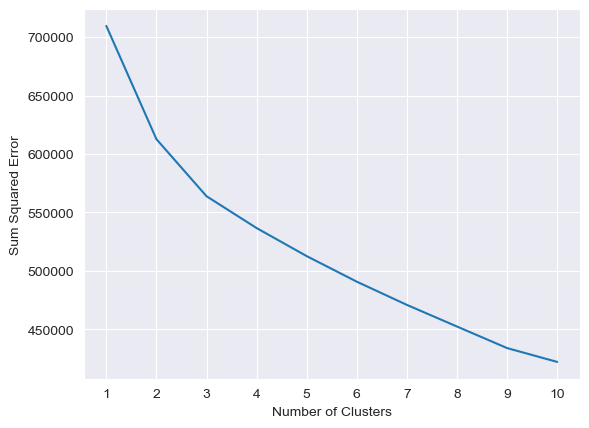

In [34]:
# calculate optimal num clusters
errors = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init="random", n_init=10, random_state=64)
    kmeans.fit(scaled_df)
    errors.append(kmeans.inertia_)

plt.plot(range(1, 11), errors)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Sum Squared Error")
plt.show()

In [35]:
# Elbow at 3 clusters
kmeans = KMeans(init="random", n_clusters=3, n_init=10, random_state=64)
kmeans.fit(scaled_df)
kmeans.labels_

array([2, 2, 0, ..., 2, 0, 2], dtype=int32)

In [41]:
df['cluster'] = kmeans.labels_
print(df)

       year  duration_ms  danceability  energy  key  loudness  mode  \
0      2004       222200         0.355   0.918    1    -4.360     1   
1      2006       258613         0.409   0.892    2    -4.373     1   
2      1991       218920         0.508   0.826    4    -5.783     0   
3      2004       237026         0.279   0.664    9    -8.851     1   
4      2008       238640         0.515   0.430    7    -9.935     1   
...     ...          ...           ...     ...  ...       ...   ...   
50678  2008       273440         0.438   0.933    6    -3.062     0   
50679  2004       275133         0.351   0.693    0    -6.811     1   
50680  2014       254826         0.434   0.975   10    -3.092     0   
50681  2008       243293         0.513   0.902    4    -3.914     0   
50682  2008       131960         0.190   0.953    8    -4.144     1   

       speechiness  acousticness  instrumentalness  liveness  valence  \
0           0.0746      0.001190          0.000000    0.0971    0.240   
1